예제 3.9 로지스틱 회귀

In [ ]:
# 예제 3.9 로지스틱 회귀(이진 분류)

# 셋업
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# 학습 데이터 준비
x_train = np.array([[1, 1, 0], [1, 0, 0], [0, 0, 1], [0, 1, 1]])   # 학습 데이터
y_train = np.array([[0], [0], [1], [1]])                           # 레이블

# 모델 생성
model = Sequential([
    Dense(1,                                          # 출력층 뉴런 1개
          activation='sigmoid',                       # sigmoid 함수 사용
          kernel_initializer=RandomNormal(seed=77),   # 가중치 초기화
          input_shape=(3, ))                          # 입력 특징 3개
])

In [ ]:
# 모델 컴파일
model.compile(loss='binary_crossentropy',
                                # 손실 함수 binary_crossentropy 사용
              optimizer=Adam(learning_rate=0.1))   # 학습률 0.1

In [ ]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=30, verbose=0)   # 30회 반복

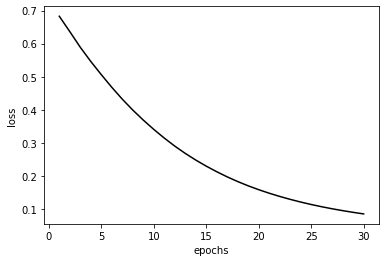

In [ ]:
# 학습 결과 시각화
epochs = range(1, len(history.history['loss']) + 1)

plt.plot(epochs, history.history['loss'], color='black')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [ ]:
# 모델 예측
x_test = np.array([[1, 1, 0], [1, 0, 0], [0, 0, 1], [0, 1, 1]])  # 테스트 데이터
y_test = np.array([[0], [0], [1], [1]])                          # 테스트 정답

model.predict(x_test).round(2)   # 예측

1/1 [==============================] - 0s 51ms/step


array([[0.08],
       [0.08],
       [0.92],
       [0.93]], dtype=float32)

In [ ]:
# 학습 후 가중치와 바이어스 확인
weights, bias = model.layers[0].get_weights()

print(f"weights: {weights.round(2)} \n bias: {bias.round(2)}")

weights: [[-2.48]
 [ 0.03]
 [ 2.48]] 
 bias: [0.01]
